# Contrastive CLIPasso

Generate sketches of images with optional **contrastive mode** — like Pictionary,
draw one image so it's clearly distinguishable from another.

## Setup

Make sure you've followed the installation steps in `README.md` before running this notebook.
The key dependencies are: PyTorch, diffvg, CLIP, and the packages in `requirements.txt`.

In [1]:
# If running in Colab, install dependencies first:
# !pip install ftfy regex tqdm scipy scikit-image matplotlib imageio Pillow svgwrite svgpathtools
# !pip install git+https://github.com/openai/CLIP.git
# !git clone https://github.com/BachiLi/diffvg.git && cd diffvg && git submodule update --init --recursive && python setup.py install && cd ..

In [2]:
import sys
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from IPython.display import display, SVG

# Add project root to path if needed
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.5.1+cu124
CUDA available: True
GPU: NVIDIA A40


---
## 1. Prepare Images

Place your images in the `target_images/` directory, or specify full paths below.

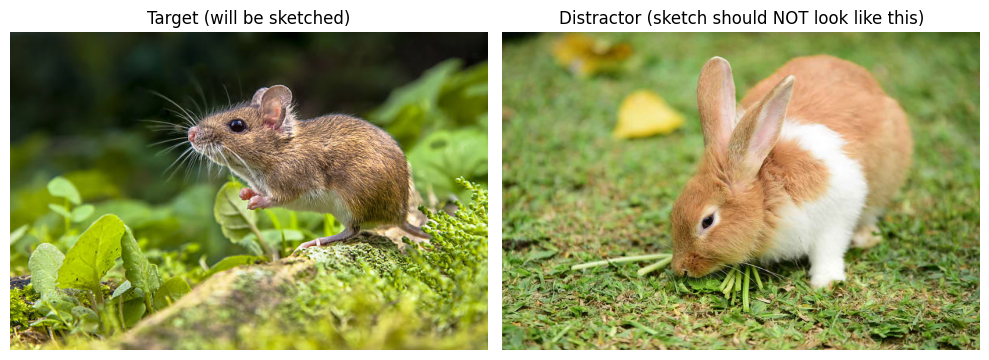

In [3]:
# === EDIT THESE PATHS ===

TARGET_IMAGE = "target_images/mouse.jpg"       # Image you want to sketch
DISTRACTOR_IMAGE = "target_images/rabbit.jpg"     # Image to contrast against (set to None for normal mode)
# DISTRACTOR_IMAGE = None                       # Uncomment for normal (non-contrastive) mode

# === Display the images ===
fig, axes = plt.subplots(1, 2 if DISTRACTOR_IMAGE else 1, figsize=(10, 5))
if not isinstance(axes, np.ndarray):
    axes = [axes]

target_im = Image.open(TARGET_IMAGE).convert('RGB')
axes[0].imshow(target_im)
axes[0].set_title('Target (will be sketched)')
axes[0].axis('off')

if DISTRACTOR_IMAGE:
    distractor_im = Image.open(DISTRACTOR_IMAGE).convert('RGB')
    axes[1].imshow(distractor_im)
    axes[1].set_title('Distractor (sketch should NOT look like this)')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## 2. Configure Parameters

Adjust these to control the sketch output.

In [11]:
# === SKETCH PARAMETERS ===

NUM_STROKES = 16              # Fewer strokes = more abstract (try 4, 8, 16, 32)
NUM_ITER = 1000               # More iterations = better quality (500-2000)
CONTRASTIVE_WEIGHT = 0.7      # How much to push away from distractor (0.0-1.0)
                              # 0.3 = subtle contrast, 0.7 = strong contrast
STROKE_WIDTH = 1           # Stroke thickness
IMAGE_SCALE = 224             # Resolution (224 is standard)
SEED = 42                     # Random seed for reproducibility
CLIP_MODEL = 'ViT-B/32'          # CLIP backbone: 'RN101', 'RN50', 'ViT-B/32'
MASK_OBJECT = True           # Set True if image has a busy background
FIX_SCALE = True             # Set True if image is not square

OUTPUT_DIR = 'outputs/notebook_run'

mode = 'contrastive' if DISTRACTOR_IMAGE else 'normal'
print(f'Mode: {mode}')
print(f'Strokes: {NUM_STROKES}, Iterations: {NUM_ITER}')
if DISTRACTOR_IMAGE:
    print(f'Contrastive weight (lambda): {CONTRASTIVE_WEIGHT}')

Mode: contrastive
Strokes: 16, Iterations: 1000
Contrastive weight (lambda): 0.7


---
## 3. Run Sketch Generation

This will take a few minutes on GPU, longer on CPU.

In [ ]:
from contrastive_clipasso import sketch

result = sketch.run(
    target=TARGET_IMAGE,
    distractor=DISTRACTOR_IMAGE,
    num_strokes=NUM_STROKES,
    num_iter=NUM_ITER,
    contrastive_weight=CONTRASTIVE_WEIGHT,
    output_dir=OUTPUT_DIR,
    image_scale=IMAGE_SCALE,
    width=STROKE_WIDTH,
    seed=SEED,
    clip_model_name=CLIP_MODEL,
    mask_object=MASK_OBJECT,
    fix_scale=FIX_SCALE,
    use_gpu=True,
    verbose=True,
)

print(f"\nDone! Best loss: {result['best_loss']:.4f} at iteration {result['best_iter']}")


  Contrastive CLIPasso — CONTRASTIVE mode
  Target:     target_images/mouse.jpg
  Distractor: target_images/rabbit.jpg
  λ (weight): 0.7
  Strokes:    16
  Iterations: 1000
  Device:     cuda
  Output:     outputs/notebook_run



/data/kushinm/repos/contrastive-sketching/./contrastive_clipasso/utils.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(model_dir))


  diffvg GPU unavailable, switching to CPU rendering.


Optimising:   0%|          | 0/1000 [00:00<?, ?it/s]

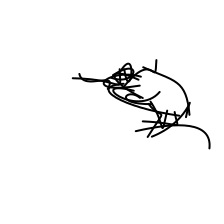

In [ ]:
# Display the best sketch as SVG (vector)
svg_path = os.path.join(OUTPUT_DIR, 'best_iter.svg')
if os.path.exists(svg_path):
    display(SVG(svg_path))
else:
    print('No best_iter.svg found — check output directory.')

In [ ]:
result = sketch.run(
    target=TARGET_IMAGE,
    distractor=None,
    num_strokes=NUM_STROKES,
    num_iter=NUM_ITER,
    contrastive_weight=CONTRASTIVE_WEIGHT,
    output_dir= 'outputs/notebook_run_non_contrastive',
    image_scale=IMAGE_SCALE,
    width=STROKE_WIDTH,
    seed=SEED,
    clip_model_name=CLIP_MODEL,
    mask_object=MASK_OBJECT,
    fix_scale=FIX_SCALE,
    use_gpu=True,
    verbose=True,
)

print(f"\nDone! Best loss: {result['best_loss']:.4f} at iteration {result['best_iter']}")


  Contrastive CLIPasso — NORMAL mode
  Target:     target_images/mouse.jpg
  Strokes:    16
  Iterations: 1000
  Device:     cuda
  Output:     outputs/notebook_run_non_contrastive



/data/kushinm/repos/contrastive-sketching/./contrastive_clipasso/utils.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(model_dir))


  diffvg GPU unavailable, switching to CPU rendering.


Optimising:   0%|          | 0/1000 [00:00<?, ?it/s]

  Best iteration: 750, loss: 0.0205
  Final sketch saved to outputs/notebook_run_non_contrastive/final_sketch.png
  SVG saved to outputs/notebook_run_non_contrastive/best_iter.svg

Done! Best loss: 0.0205 at iteration 750


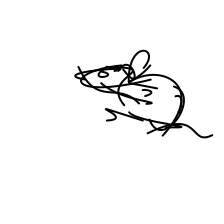

In [ ]:
# Display the best sketch as SVG (vector)
svg_path = os.path.join('outputs/notebook_run_non_contrastive', 'best_iter.svg')
if os.path.exists(svg_path):
    display(SVG(svg_path))
else:
    print('No best_iter.svg found — check output directory.')

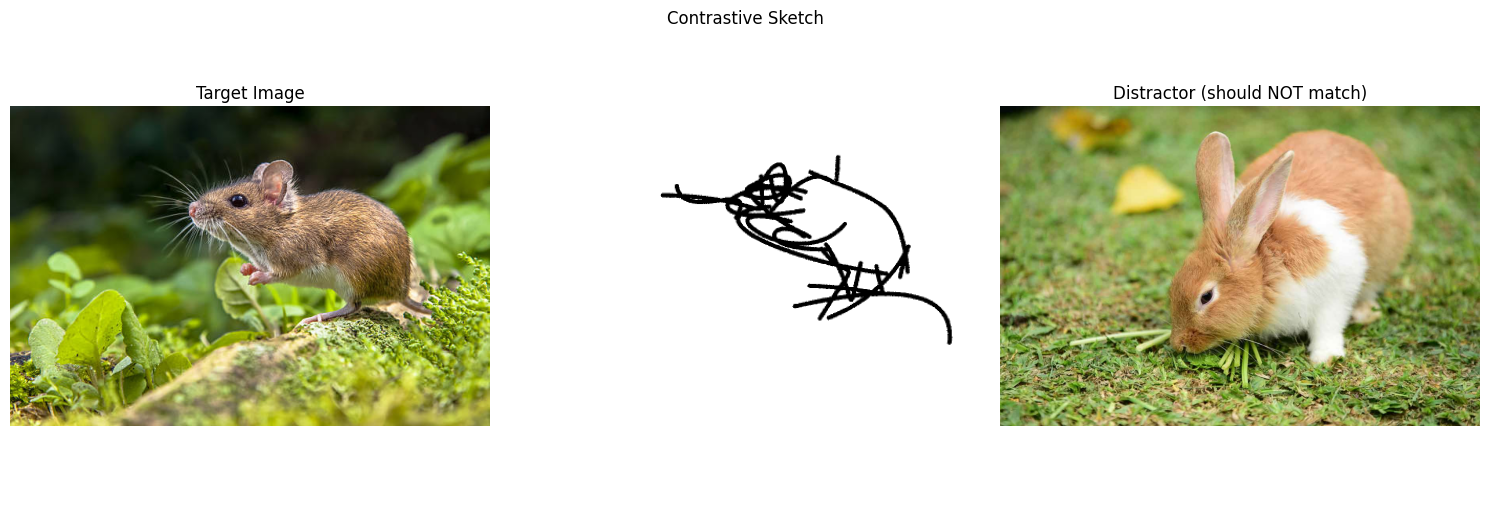

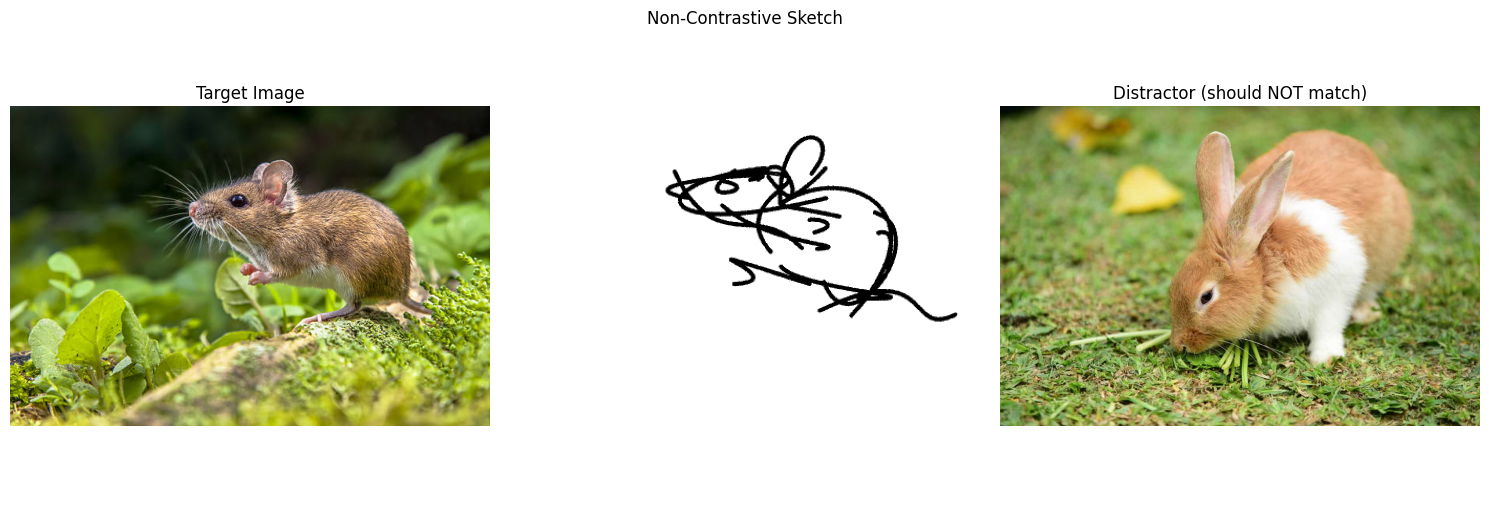

In [ ]:
# Side-by-side comparison
ncols = 3 if DISTRACTOR_IMAGE else 2
fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))

# Target
axes[0].imshow(Image.open(TARGET_IMAGE).convert('RGB'))
axes[0].set_title('Target Image')
axes[0].axis('off')

# Sketch
sketch_path = os.path.join(OUTPUT_DIR, 'final_sketch.png')
if os.path.exists(sketch_path):
    axes[1].imshow(Image.open(sketch_path))
else:
    # Fall back to best_iter.jpg
    axes[1].imshow(Image.open(os.path.join(OUTPUT_DIR, 'best_iter.jpg')))
title = 'Contrastive Sketch' if DISTRACTOR_IMAGE else 'Sketch'
axes[1].set_title(title)
axes[1].axis('off')

# Distractor
if DISTRACTOR_IMAGE:
    axes[2].imshow(Image.open(DISTRACTOR_IMAGE).convert('RGB'))
    axes[2].set_title('Distractor (should NOT match)')
    axes[2].axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))

# Target
axes[0].imshow(Image.open(TARGET_IMAGE).convert('RGB'))
axes[0].set_title('Target Image')
axes[0].axis('off')

# Sketch
sketch_path = os.path.join('outputs/notebook_run_non_contrastive', 'final_sketch.png')
if os.path.exists(sketch_path):
    axes[1].imshow(Image.open(sketch_path))
else:
    # Fall back to best_iter.jpg
    axes[1].imshow(Image.open(os.path.join(OUTPUT_DIR, 'best_iter.jpg')))
title = 'Non-Contrastive Sketch' if DISTRACTOR_IMAGE else 'Sketch'
axes[1].set_title(title)
axes[1].axis('off')

# Distractor
if DISTRACTOR_IMAGE:
    axes[2].imshow(Image.open(DISTRACTOR_IMAGE).convert('RGB'))
    axes[2].set_title('Distractor (should NOT match)')
    axes[2].axis('off')

plt.tight_layout()
plt.show()




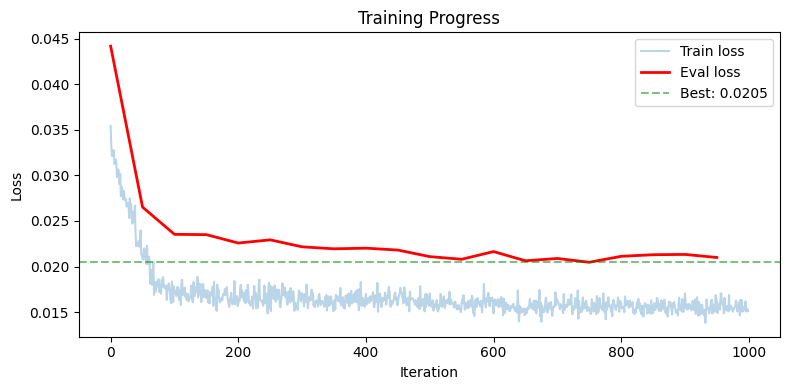

In [ ]:
# Plot loss over training
fig, ax = plt.subplots(figsize=(8, 4))

if result.get('loss_train'):
    ax.plot(result['loss_train'], alpha=0.3, label='Train loss')
if result.get('loss_eval'):
    eval_x = list(range(0, len(result['loss_eval']) * max(1, NUM_ITER // max(len(result['loss_eval']), 1)), 
                        max(1, NUM_ITER // max(len(result['loss_eval']), 1))))
    eval_x = eval_x[:len(result['loss_eval'])]
    ax.plot(eval_x, result['loss_eval'], 'r-', label='Eval loss', linewidth=2)
    ax.axhline(y=result['best_loss'], color='g', linestyle='--', alpha=0.5, label=f'Best: {result["best_loss"]:.4f}')

ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Training Progress')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Compare Normal vs Contrastive

Run the same target with and without a distractor to see how the sketch changes.

In [ ]:
# Run normal mode (no distractor)
result_normal = sketch.run(
    target=TARGET_IMAGE,
    distractor=None,
    num_strokes=NUM_STROKES,
    num_iter=NUM_ITER,
    output_dir='outputs/compare_normal',
    seed=SEED,
    use_gpu=True,
    mask_object=MASK_OBJECT,
    fix_scale=FIX_SCALE,

)

# Run contrastive mode
if DISTRACTOR_IMAGE:
    result_contrastive = sketch.run(
        target=TARGET_IMAGE,
        distractor=DISTRACTOR_IMAGE,
        num_strokes=NUM_STROKES,
        num_iter=NUM_ITER,
        contrastive_weight=CONTRASTIVE_WEIGHT,
        output_dir='outputs/compare_contrastive',
        seed=SEED,
        use_gpu=True,
        mask_object=MASK_OBJECT,
        fix_scale=FIX_SCALE,
   
    )

In [ ]:
# Compare the two sketches
if DISTRACTOR_IMAGE:
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    axes[0].imshow(Image.open(TARGET_IMAGE).convert('RGB'))
    axes[0].set_title('Target')
    axes[0].axis('off')
    
    normal_sketch = os.path.join('outputs/compare_normal', 'final_sketch.png')
    if os.path.exists(normal_sketch):
        axes[1].imshow(Image.open(normal_sketch))
    axes[1].set_title('Normal Sketch')
    axes[1].axis('off')
    
    contrastive_sketch = os.path.join('outputs/compare_contrastive', 'final_sketch.png')
    if os.path.exists(contrastive_sketch):
        axes[2].imshow(Image.open(contrastive_sketch))
    axes[2].set_title(f'Contrastive Sketch (λ={CONTRASTIVE_WEIGHT})')
    axes[2].axis('off')
    
    axes[3].imshow(Image.open(DISTRACTOR_IMAGE).convert('RGB'))
    axes[3].set_title('Distractor')
    axes[3].axis('off')
    
    plt.suptitle('Normal vs Contrastive Sketching', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('Set DISTRACTOR_IMAGE above to compare modes.')

---
## 6. Sweep Contrastive Weight (λ)

See how different contrastive weights affect the sketch.
Higher λ = more emphasis on being different from the distractor.

In [ ]:
# Sweep different contrastive weights
LAMBDAS = [0.0, 0.3, 0.5, 0.7, 1.0]
SWEEP_ITER = 500  # Fewer iterations for speed

if DISTRACTOR_IMAGE:
    sweep_results = {}
    for lam in LAMBDAS:
        print(f'\n--- λ = {lam} ---')
        out = f'outputs/sweep_lambda_{lam}'
        sweep_results[lam] = sketch.run(
            target=TARGET_IMAGE,
            distractor=DISTRACTOR_IMAGE if lam > 0 else None,
            num_strokes=NUM_STROKES,
            num_iter=SWEEP_ITER,
            contrastive_weight=lam,
            output_dir=out,
            seed=SEED,
            use_gpu=True,
            verbose=False,
            mask_object=MASK_OBJECT,
            fix_scale=FIX_SCALE
        )
    
    fig, axes = plt.subplots(1, len(LAMBDAS) + 2, figsize=(4 * (len(LAMBDAS) + 2), 4))
    
    axes[0].imshow(Image.open(TARGET_IMAGE).convert('RGB'))
    axes[0].set_title('Target')
    axes[0].axis('off')
    
    for i, lam in enumerate(LAMBDAS):
        out_path = f'outputs/sweep_lambda_{lam}/final_sketch.png'
        if os.path.exists(out_path):
            axes[i + 1].imshow(Image.open(out_path))
        axes[i + 1].set_title(f'λ = {lam}')
        axes[i + 1].axis('off')
    
    axes[-1].imshow(Image.open(DISTRACTOR_IMAGE).convert('RGB'))
    axes[-1].set_title('Distractor')
    axes[-1].axis('off')
    
    plt.suptitle('Effect of Contrastive Weight (λ)', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('Set DISTRACTOR_IMAGE to run the sweep.')